In [1]:
import os
import pandas as pd
from prettytable import PrettyTable
import matplotlib.pyplot as plt

from lib.uncertinay_rat import SimulateRat

/Users/felix/MSE/03_projects/MT/zz_code/04_experiments/03_analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DS_FEVER = '../02_data/2026-05-11_k/fever'
DS_HOTPOTQA = '../02_data/2026-05-11_k/hotpotqa'
DS_NQ = '../02_data/2026-05-11_k/nq'

In [3]:
def get_retrieval_success(row):
    ret_set = set([f"{r['document_id']}:{r['index']}" for r in row['retrieved']])
    ref_set = set([f"{r['document_id']}:{r['index']}" for r in row['reference']])

    return set(ref_set) <= set(ret_set)

def set_abstain(row):
    return (row['generated_answer'] == 'I DO NOT KNOW') or (row['generated_answer'] == 'NOT ENOUGH INFO')

def set_task_success(row):
    return row['correct_answer']

def set_generator_success(row):
    if row['retriever_success'] == True:
        return row['task_success']
    else:
        return row['abstain']

In [4]:
results_all = {}
success_rates = {}
samples_all = {}

simulate = SimulateRat()

def load(base, g, experiment):
    try:
        id = experiment.split('_')
        results = pd.read_json(f'{base}/{g}/{experiment}/results.json')
        k = id[-1]
        r = id[-3]
        dataset = id[-4]

        results['dataset'] = dataset
        results['generator'] = g
        results['retriever_strategy'] = r

        results['correct_query'] = True
        results['retriever_success'] = results.apply(get_retrieval_success, axis=1)
        results['abstain'] = results.apply(set_abstain, axis=1)
        results['task_success'] = results.apply(set_task_success, axis=1)
        results['generator_success'] = results.apply(set_generator_success, axis=1)

        results['k'] = int(k.replace("k", ""))

        key = f"{dataset}_{g}_{r}_{k}"
        results_all[key] = results
    except:
        return

for g in os.listdir(f"{DS_FEVER}"):
    for experiment in os.listdir(f"{DS_FEVER}/{g}/"):
        load(DS_FEVER, g, experiment)

for g in os.listdir(f"{DS_HOTPOTQA}"):
    for experiment in os.listdir(f"{DS_HOTPOTQA}/{g}/"):
        load(DS_HOTPOTQA, g, experiment)

for g in os.listdir(f"{DS_NQ}"):
    for experiment in os.listdir(f"{DS_NQ}/{g}/"):
        load(DS_NQ, g, experiment)

out = pd.concat((df for df in results_all.values()), ignore_index=True)
out = out.sort_values(['dataset', 'generator', 'retriever_strategy', 'k'])


In [5]:
out = out.sort_values(['dataset', 'generator', 'retriever_strategy', 'k'])

In [6]:
t = PrettyTable(field_names=['Dataset', 'Generator', 'Retriever Strategy', 'k', 'P(R=1)', 'P(A=1)', 'P(T=1)', 'P(G=1)'])

for experiment in results_all.keys():
    id = experiment.split('_')
    k = int(id[-1].replace("k", ""))    
    df = out.loc[(out['dataset'] == id[0]) & (out['generator'] == id[1]) & (out['retriever_strategy'] == id[2]) & (out['k'] == k)]

    t.add_row([
        id[0],
        id[1],
        id[2],
        k,
        f"{df['retriever_success'].mean():.2f}",
        f"{df['abstain'].mean():.2f}",
        f"{df['task_success'].mean():.2f}",
        f"{df['generator_success'].mean():.2f}"
    ]) 
 
t

Dataset,Generator,Retriever Strategy,k,P(R=1),P(A=1),P(T=1),P(G=1)
fever,qwen,sparse,100,0.89,0.03,0.91,0.82
fever,qwen,hybrid,20,0.85,0.04,0.90,0.81
fever,qwen,sparse,5,0.53,0.18,0.77,0.65
fever,qwen,hybrid,5,0.63,0.12,0.83,0.68
fever,qwen,dense,10,0.70,0.15,0.80,0.78
fever,qwen,dense,5,0.58,0.21,0.75,0.73
fever,qwen,hybrid,10,0.77,0.06,0.89,0.76
fever,qwen,dense,100,0.81,0.10,0.84,0.84
fever,qwen,sparse,10,0.64,0.11,0.84,0.68
fever,qwen,sparse,20,0.74,0.06,0.88,0.73


In [7]:
metrics = {
    'retriever_success': 'Retriever Success',
    'abstain': 'Abstain',
    'task_success': 'Task Success',
}

strategies = ['sparse', 'dense', 'hybrid']

def plot_metrics(axes, df):
    for metric, ax in zip(metrics.keys(), axes):
        for strat in strategies:
            subset = df[df["retriever_strategy"] == strat].sort_values("k")

            ks = subset["k"].unique()
            metric_mean = subset.groupby('k')[metric].mean().to_list()

            ax.plot(ks, metric_mean, marker="o", label=strat.capitalize())

        ax.set_title(metrics[metric])
        ax.set_xlabel("k")
        ax.legend()
        ax.grid()
        ax.set_ylim(0, 1)


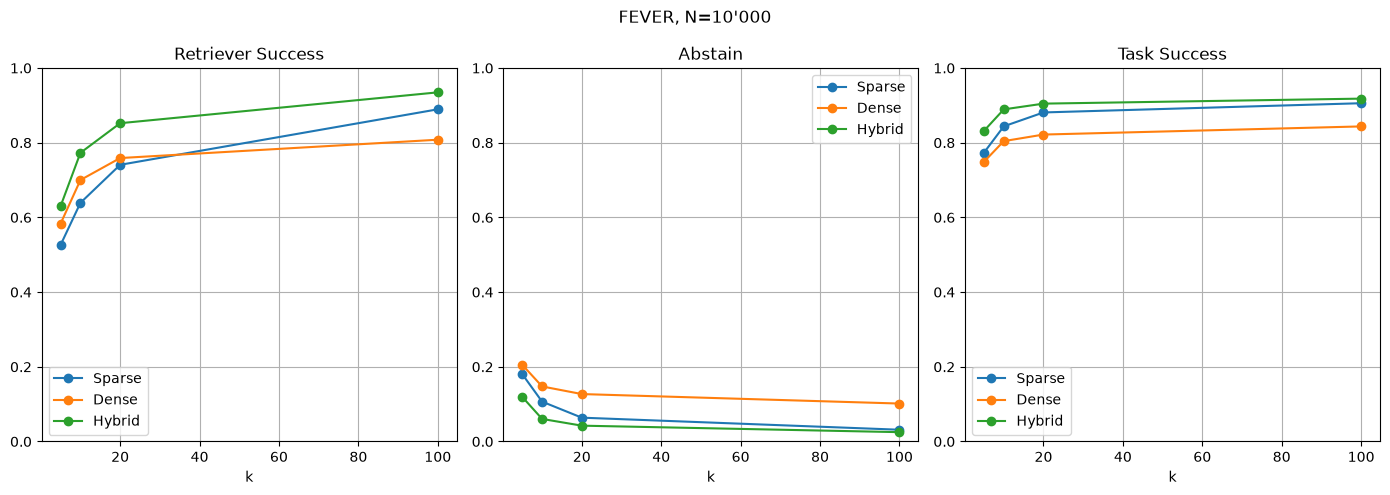

In [8]:
df = out.loc[(out['dataset'] == 'fever') & (out['generator'] == 'qwen')]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
plot_metrics(axes, df)
plt.suptitle("FEVER, N=10'000")
plt.tight_layout()
plt.show()

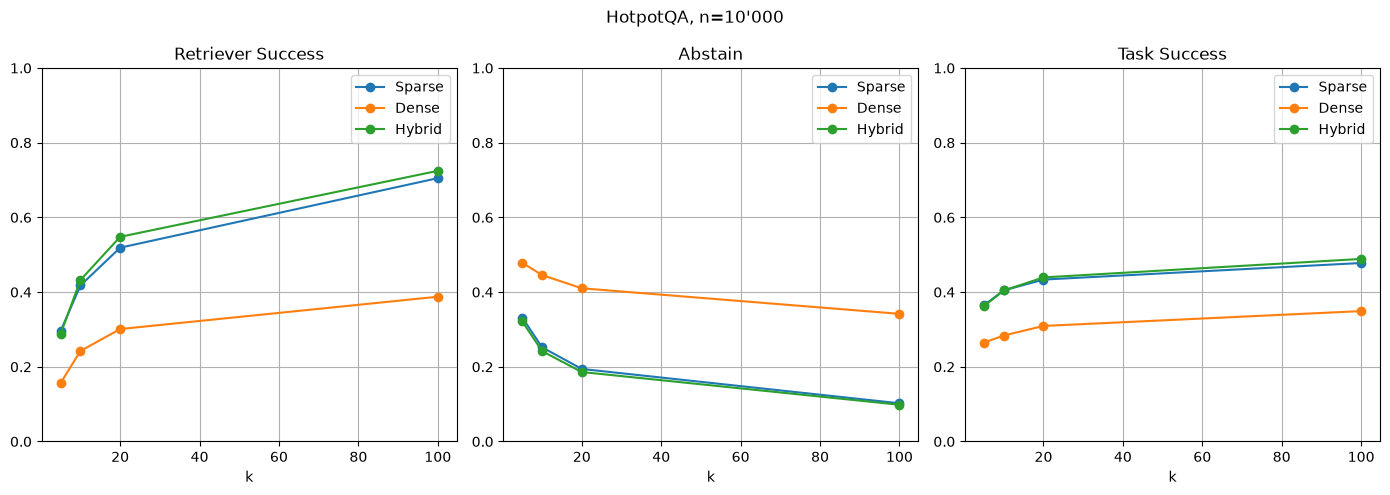

In [9]:
df = out.loc[(out['dataset'] == 'hotpotqa') & (out['generator'] == 'qwen')]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
plot_metrics(axes, df)
plt.suptitle("HotpotQA, n=10'000")
plt.tight_layout()
plt.show()

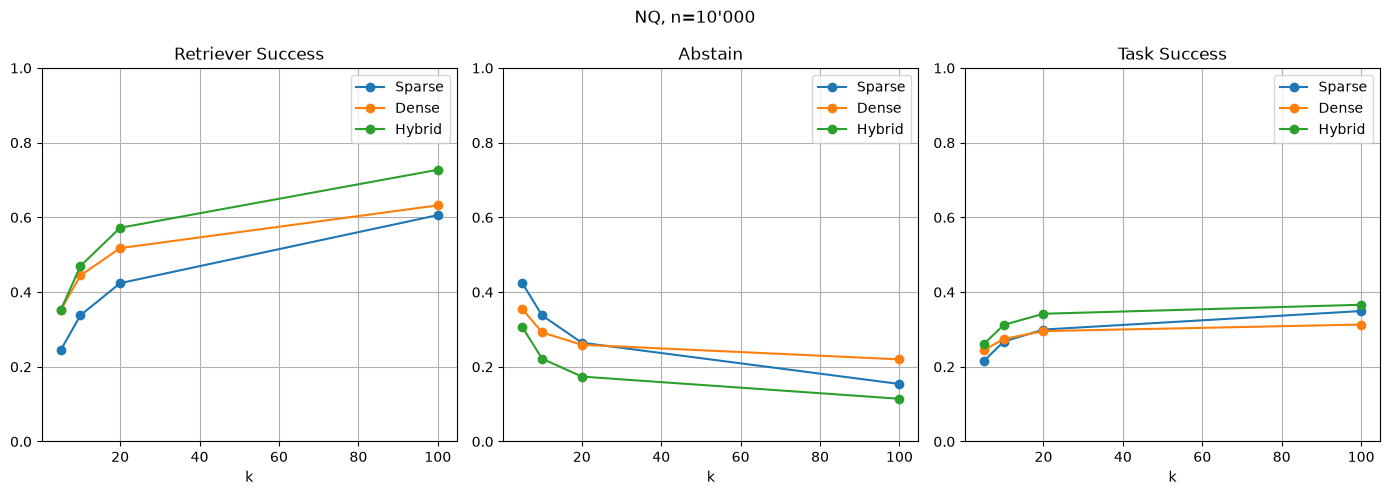

In [10]:
df = out.loc[(out['dataset'] == 'nq') & (out['generator'] == 'qwen')]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
plot_metrics(axes, df)
plt.suptitle("NQ, n=10'000")
plt.tight_layout()
plt.show()